# AQI Dataset — EDA
Covers: overview, missingness, target distribution, correlations, temporal patterns, weather distributions, and pollutant profiles.

In [1]:
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns

from datetime import datetime, timedelta
import pandas as pd
from openmeteo_requests import Client
from requests_cache import CachedSession
from retry_requests import retry
from numpy import cos, sin, radians
from pandas import date_range, to_datetime, Timedelta, DataFrame

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 11, 'axes.labelsize': 10})

WEATHER_COLS = [
    'temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
    'wind_speed_10m', 'wind_gusts_10m', 'surface_pressure',
    'precipitation', 'cloud_cover', 'shortwave_radiation',
]
POLLUTANT_COLS = ['pm10', 'pm2_5', 'carbon_monoxide',
                  'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']
TARGET = 'us_aqi'

## 1. Load Data

In [3]:
def fetch_openmeteo_data(days: int = 92):
    """
    Fetch data directly from OpenMeteo for the past N days.
    Returns a processed DataFrame ready for EDA.
    """
    # Calculate date range
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days)
    
    # Format dates for API
    start_date_str = start_date.strftime("%Y-%m-%d")
    end_date_str = end_date.strftime("%Y-%m-%d")
    
    print(f"Fetching data from {start_date_str} to {end_date_str}")
    
    # Coordinates for Rawalpindi
    latitude = 33.5973
    longitude = 73.0479
    
    # API URLs
    features_url = "https://api.open-meteo.com/v1/forecast"
    targets_url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    
    # Parameters for weather features
    feature_params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": WEATHER_COLS.copy(),
        "start_date": start_date_str,
        "end_date": end_date_str,
        "timezone": "auto",
    }
    
    # Parameters for pollutants and AQI
    target_params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": POLLUTANT_COLS + [TARGET],
        "start_date": start_date_str,
        "end_date": end_date_str,
        "timezone": "auto",
    }
    
    # Setup OpenMeteo client with caching and retry
    cache_session = CachedSession(".cache", expire_after=3600)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = Client(session=retry_session)
    
    # Fetch data
    print("Fetching weather features...")
    raw_features = openmeteo.weather_api(url=features_url, params=feature_params)[0]
    
    print("Fetching air quality data...")
    raw_targets = openmeteo.weather_api(url=targets_url, params=target_params)[0]
    
    # Extract hourly data
    hourly_raw_features = raw_features.Hourly()
    hourly_raw_targets = raw_targets.Hourly()
    
    # Build features dataframe
    features_data = {
        "datetime": date_range(
            start=to_datetime(hourly_raw_features.Time(), unit='s', utc=True),
            end=to_datetime(hourly_raw_features.TimeEnd(), unit='s', utc=True),
            freq=Timedelta(seconds=hourly_raw_features.Interval()),
            inclusive="left"
        )
    }
    
    # Add weather features
    for index, feature in enumerate(feature_params["hourly"]):
        features_data[feature] = hourly_raw_features.Variables(index).ValuesAsNumpy()
    
    # Build targets dataframe
    targets_data = {
        "datetime": date_range(
            start=to_datetime(hourly_raw_targets.Time(), unit='s', utc=True),
            end=to_datetime(hourly_raw_targets.TimeEnd(), unit='s', utc=True),
            freq=Timedelta(seconds=hourly_raw_targets.Interval()),
            inclusive="left"
        )
    }
    
    # Add pollutants and target
    for index, feature in enumerate(target_params["hourly"]):
        targets_data[feature] = hourly_raw_targets.Variables(index).ValuesAsNumpy()
    
    # Create dataframes
    features_df = DataFrame(features_data)
    targets_df = DataFrame(targets_data)
    
    # Merge features and targets
    df = pd.merge(features_df, targets_df, on="datetime", how="inner")
    
    # Convert UTC datetime to local Pakistan time
    df["datetime"] = df["datetime"].dt.tz_convert("Asia/Karachi")
    df = df.sort_values("datetime").reset_index(drop=True)
    
    # Handle missing values
    missing_before = df.isnull().sum().sum()
    print(f"Missing values before handling: {missing_before}")
    
    # Forward fill for short gaps, then backward fill
    df = df.fillna(method='ffill', limit=2)
    df = df.fillna(method='bfill', limit=1)
    
    # Drop any remaining rows with missing values
    initial_rows = len(df)
    df = df.dropna()
    
    if len(df) < initial_rows:
        print(f"Dropped {initial_rows - len(df)} rows with persistent missing values")
    
    print(f"Final shape: {df.shape}")
    print(f"Date range: {df['datetime'].min()} → {df['datetime'].max()}")
    print(f"Missing values after handling: {df.isnull().sum().sum()}")
    
    return df

# Fetch the data
print("Starting data fetch...\n")
df = fetch_openmeteo_data(days=92)

# Display basic info
print(f"\nDataset Info:")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumn categories:")
print(f"  • Weather columns: {len([c for c in WEATHER_COLS if c in df.columns])}")
print(f"  • Pollutant columns: {len([c for c in POLLUTANT_COLS if c in df.columns])}")
print(f"  • Temporal columns: 6 (hour, day_of_week, month, day_of_year, season, is_weekend, is_rush_hour)")

# Show first few rows
print(f"\nFirst 5 rows:")
print(df.head())

# Check data types
print(f"\nData types:")
print(df.dtypes.value_counts())

# Summary statistics
print(f"\nSummary statistics for key columns:")
key_cols = WEATHER_COLS[:3] + POLLUTANT_COLS[:3] + [TARGET]
print(df[key_cols].describe())

Starting data fetch...

Fetching data from 2026-02-21 to 2026-05-24
Fetching weather features...
Fetching air quality data...
Missing values before handling: 3861
Dropped 428 rows with persistent missing values
Final shape: (1804, 17)
Date range: 2026-03-10 20:00:00+05:00 → 2026-05-24 23:00:00+05:00
Missing values after handling: 0

Dataset Info:
Shape: (1804, 17)
Memory usage: 0.14 MB

Column categories:
  • Weather columns: 9
  • Pollutant columns: 6
  • Temporal columns: 6 (hour, day_of_week, month, day_of_year, season, is_weekend, is_rush_hour)

First 5 rows:
                     datetime  temperature_2m  relative_humidity_2m  \
428 2026-03-10 20:00:00+05:00       23.878500                  34.0   
429 2026-03-10 21:00:00+05:00       23.878500                  34.0   
430 2026-03-10 22:00:00+05:00       22.878500                  35.0   
431 2026-03-10 23:00:00+05:00       22.528500                  37.0   
432 2026-03-11 00:00:00+05:00       22.728498                  36.0   

   

## 2. Target Distribution (`us_aqi`)

In [6]:
bins   = [0, 50, 100, 150, 200, 300, 500]
labels = ['Good', 'Moderate', 'Unhealthy(SG)', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
df['aqi_category'] = pd.cut(df[TARGET], bins=bins, labels=labels, right=True)
print(df['aqi_category'].value_counts().sort_index())

aqi_category
Good                 0
Moderate          1364
Unhealthy(SG)      369
Unhealthy           65
Very Unhealthy       6
Hazardous            0
Name: count, dtype: int64


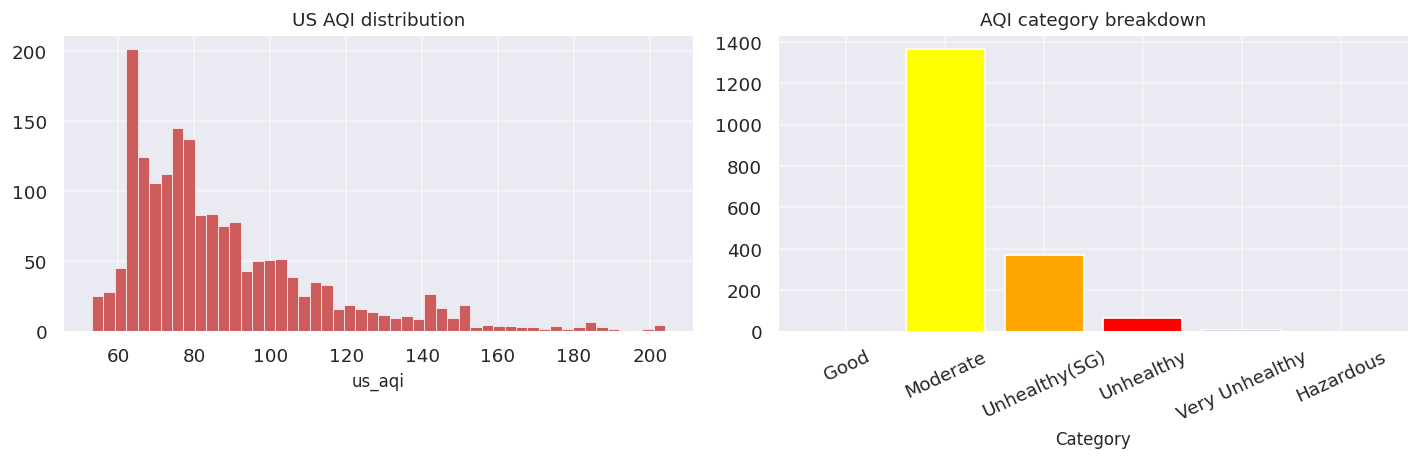

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[TARGET].dropna(), bins=50, color='indianred', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel(TARGET)
axes[0].set_title('US AQI distribution')

cat_order = [l for l in labels if l in df['aqi_category'].cat.categories]
counts = df['aqi_category'].value_counts().reindex(cat_order)
axes[1].bar(counts.index, counts.values,
            color=['green', 'yellow', 'orange', 'red', 'purple', 'maroon'][:len(counts)])
axes[1].set_xlabel('Category')
axes[1].set_title('AQI category breakdown')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()
df.drop(columns='aqi_category', inplace=True)

## 3. Correlations with Target

In [9]:
numeric = df.select_dtypes(include=np.number)
corr = numeric.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(corr.head(15).round(3).rename('pearson_r'))

pm10                    0.414
pm2_5                   0.379
sulphur_dioxide         0.378
temperature_2m          0.282
ozone                   0.226
relative_humidity_2m   -0.225
carbon_monoxide         0.073
cloud_cover            -0.066
precipitation          -0.062
nitrogen_dioxide        0.044
wind_gusts_10m          0.036
shortwave_radiation    -0.031
wind_speed_10m          0.025
surface_pressure       -0.024
dew_point_2m            0.017
Name: pearson_r, dtype: float64


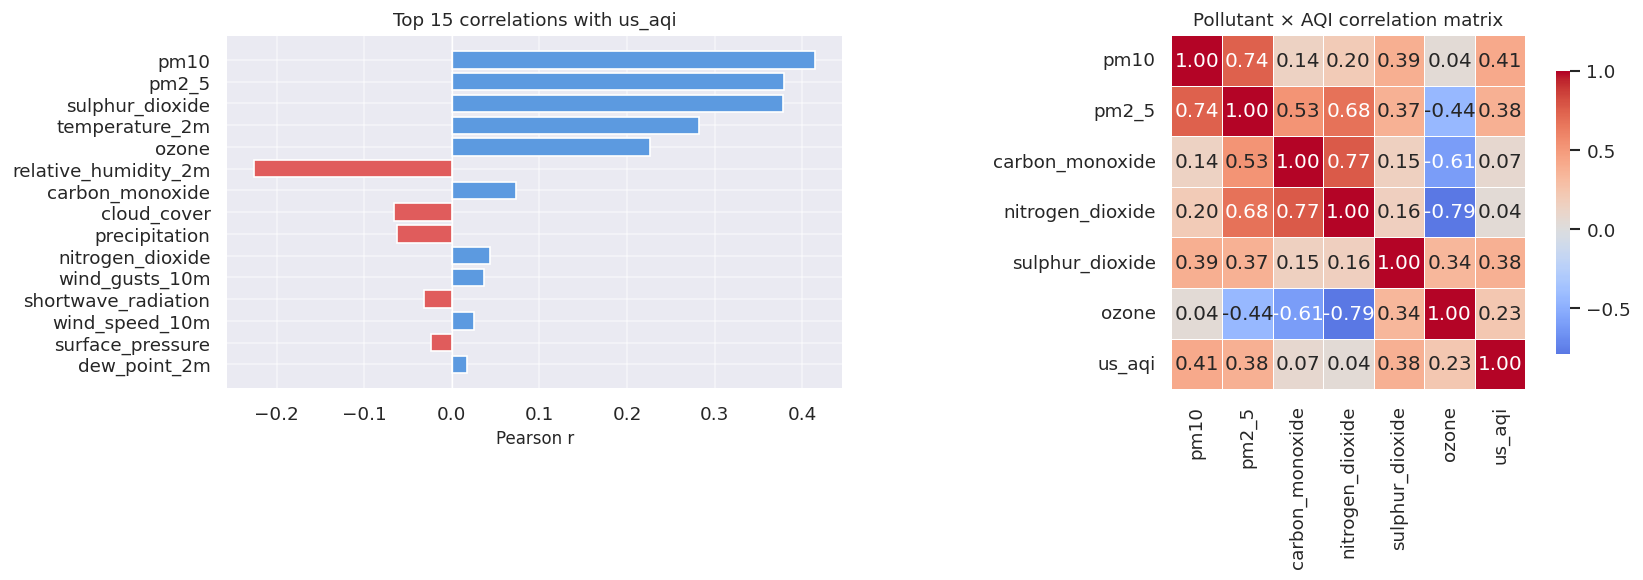

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top = corr.head(15)
colors = ['#e05c5c' if v < 0 else '#5c9ae0' for v in top.values]
axes[0].barh(top.index[::-1], top.values[::-1], color=colors[::-1])
axes[0].axvline(0, color='white', linewidth=0.8)
axes[0].set_title(f'Top 15 correlations with {TARGET}')
axes[0].set_xlabel('Pearson r')

poll_cols = [c for c in POLLUTANT_COLS + [TARGET] if c in numeric.columns]
sns.heatmap(
    numeric[poll_cols].corr(), ax=axes[1],
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
axes[1].set_title('Pollutant × AQI correlation matrix')

plt.tight_layout()
plt.show()

## 4. Temporal Patterns

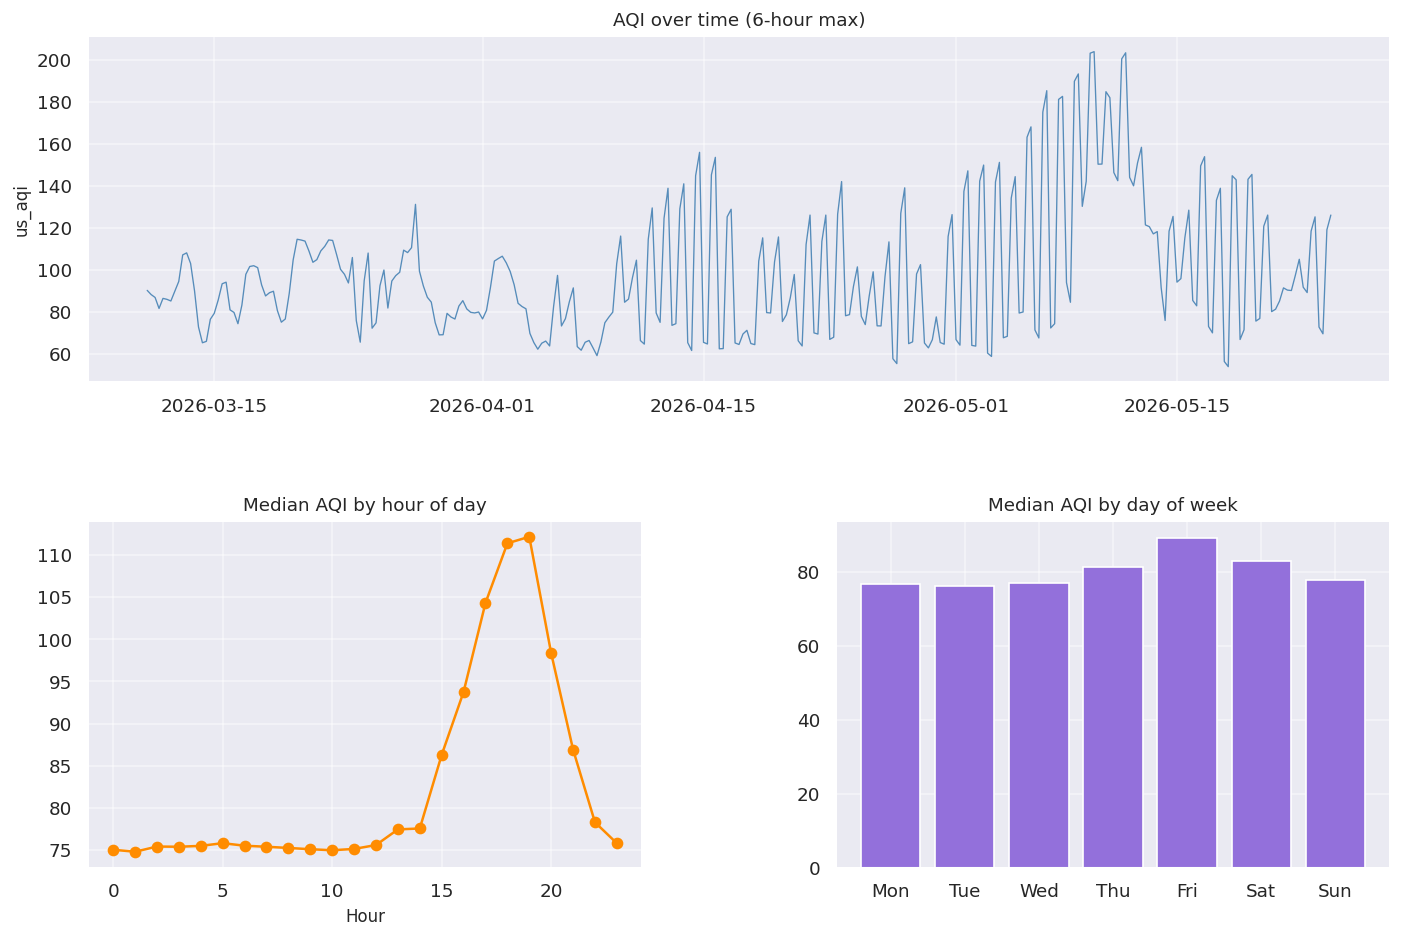

In [11]:
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# Time series
ax0 = fig.add_subplot(gs[0, :])
ts  = df.set_index('datetime')[TARGET].resample('6h').max()
ax0.plot(ts.index, ts.values, color='steelblue', linewidth=0.8, alpha=0.9)
ax0.set_title('AQI over time (6-hour max)')
ax0.set_ylabel(TARGET)

# Hour of day
ax1 = fig.add_subplot(gs[1, 0])
df.groupby(df['datetime'].dt.hour)[TARGET].median().plot(
    ax=ax1, marker='o', color='darkorange', linewidth=1.5)
ax1.set_title('Median AQI by hour of day')
ax1.set_xlabel('Hour')

# Day of week
ax2 = fig.add_subplot(gs[1, 1])
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
medians = df.groupby(df['datetime'].dt.dayofweek)[TARGET].median().reindex(range(7))
ax2.bar(dow_labels, medians.values, color='mediumpurple')
ax2.set_title('Median AQI by day of week')

plt.show()

## 5. Weather Feature Distributions

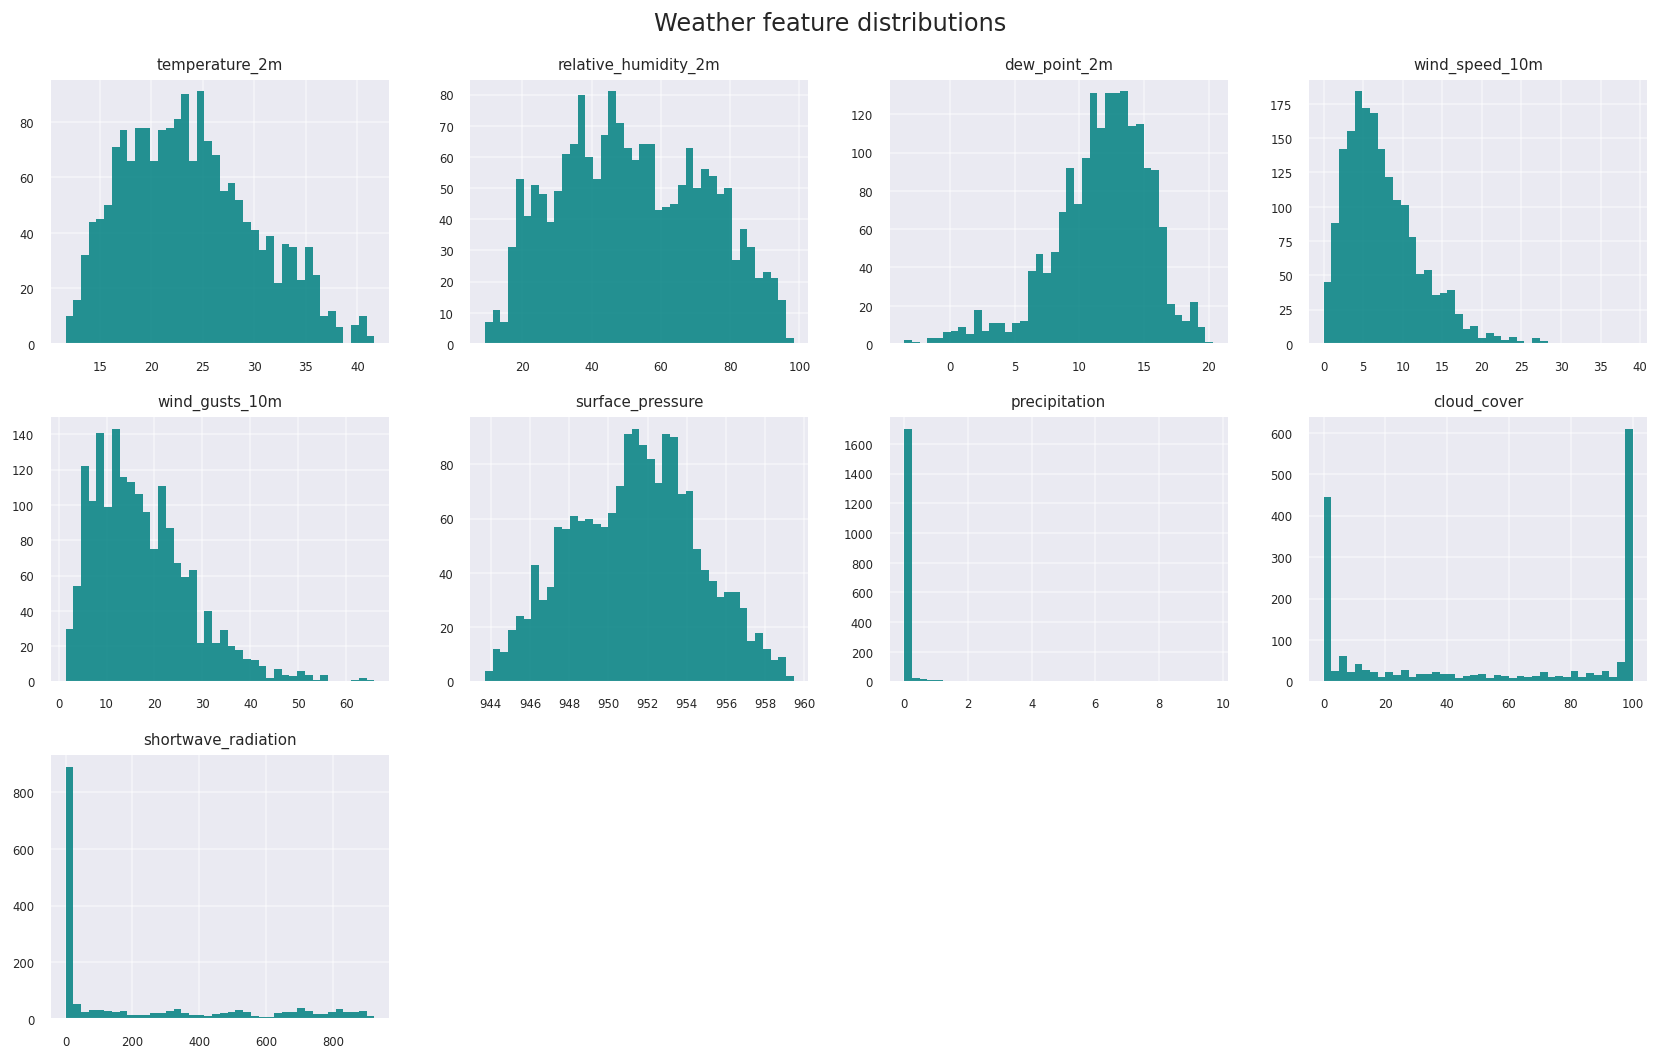

In [12]:
cols  = [c for c in WEATHER_COLS if c in df.columns]
ncols = 4
nrows = int(np.ceil(len(cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()
for i, col in enumerate(cols):
    axes[i].hist(df[col].dropna(), bins=40, color='teal', edgecolor='none', alpha=0.85)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Weather feature distributions')
plt.tight_layout()
plt.show()